In [1]:
# Import settings/
nb_settings_path = "./settings.py"
with open(nb_settings_path) as f:
    code = f.read()
    exec(code)

In [2]:
import os
import re
import math
import itertools
from typing import List
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize
from matplotlib.ticker import FormatStrFormatter

import seaborn as sns

import statsmodels.api as sm

from utils import FORMAT_N, FORMAT_D, N_color_map, D_color_map, N_ticks, D_ticks
from utils_scaling_fit import plot_diagnostic, plot_diagnostic_1d, plot_diagnostic_2d, bootstrap_test_null
from utils_plotting import plot_hp_vs_ND_fix_other, plot_hp_vs_DN

def fit(df, y, x):
    y = df[y]
    X = sm.add_constant(df[x])
    return sm.OLS(y, X).fit()


In [3]:
SEQ_LEN = 4096

# full dataset
df_all = pd.read_csv('../data/loss_all_exps_post_annealing.csv')

# best HP
df_best_lr = pd.read_csv('../data/best_HPs/lr_min.csv')
df_best_gbsz = pd.read_csv('../data/best_HPs/gbsz_min.csv')
df_best_lr_gbsz = pd.read_csv('../data/best_HPs/lr_gbsz_min.csv')

# HP from quadratic fit
df_best_lr_smooth = pd.read_csv('../data/best_HPs/lr_min_smooth.csv')
df_best_lr_sliced = pd.read_csv('../data/best_HPs/lr_min_sliced.csv')
df_best_gbsz_sliced = pd.read_csv('../data/best_HPs/gbsz_min_sliced.csv')

# Load quadratic fits
fit_2d_lr_gbsz = pd.read_parquet('../data/quadratic_fits/fit_2d_lr_gbsz.parquet')
fit_2d_sliced_lr = pd.read_parquet('../data/quadratic_fits/fit_2d_sliced_lr.parquet')
fit_2d_sliced_gbsz = pd.read_parquet('../data/quadratic_fits/fit_2d_sliced_gbsz.parquet')


# Fit

In [4]:
# Data
df = df_best_gbsz_sliced.copy()
df_fit = df[df.N != 1_713_504_256].reset_index(drop=True)

del df

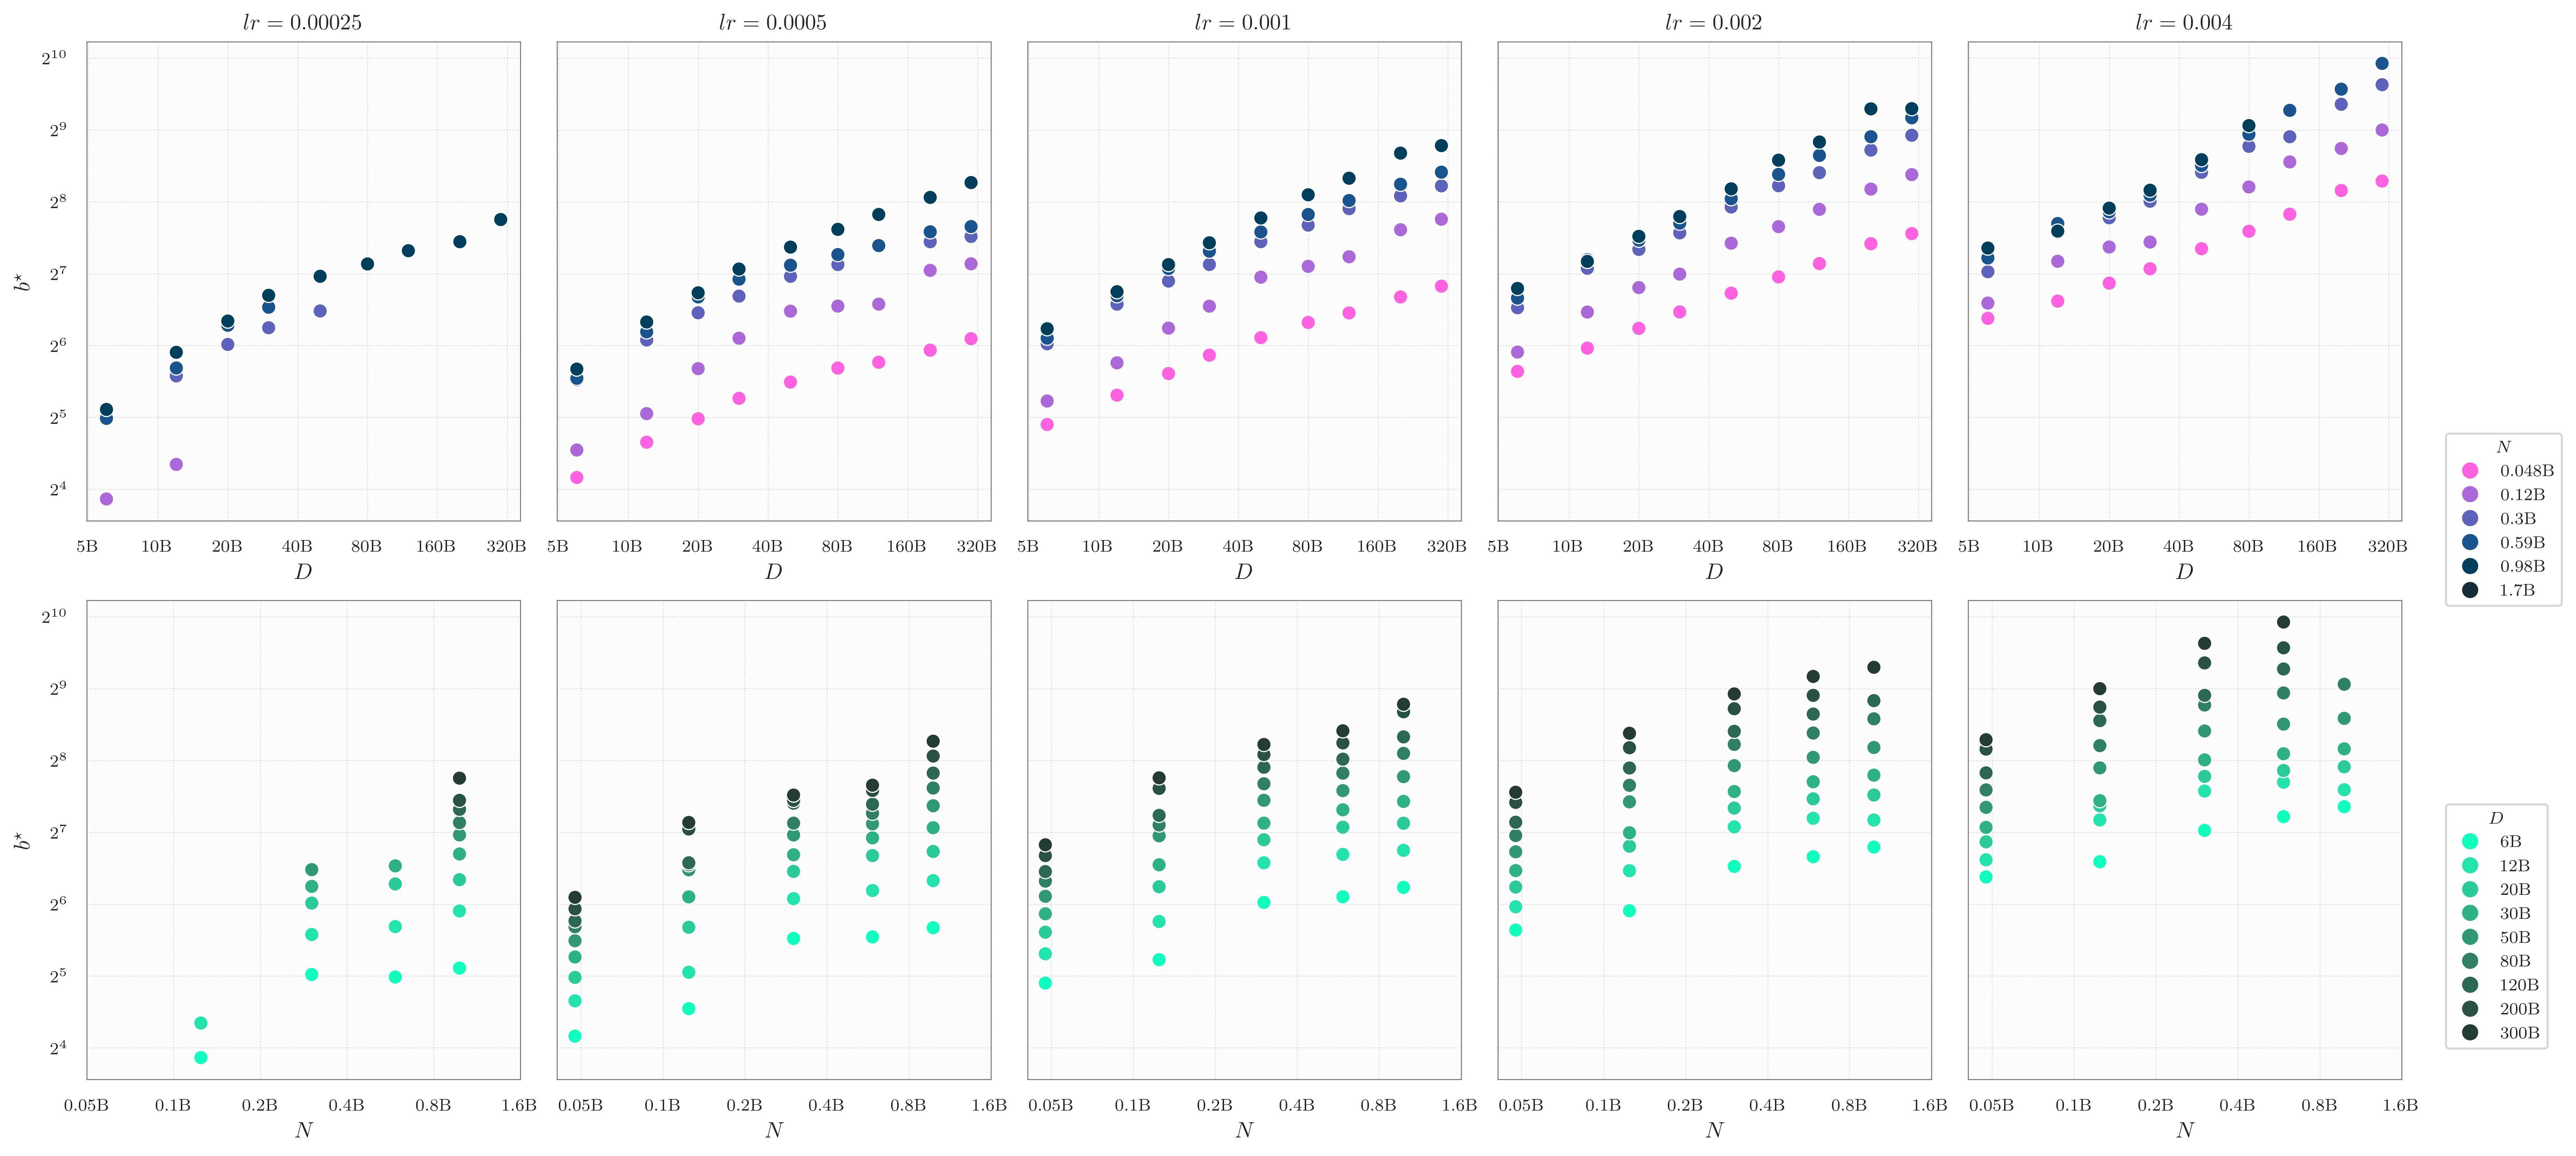

In [5]:
## Data Visualization
plot_hp_vs_ND_fix_other(
    df_fit,
    y='gbsz',
    other_fixed='lr',
)

In [6]:
# --- data prep / outlier removal ---

# Data
df = df_fit.copy()

# Drop learning rates with too few points
df = df[df.lr != 0.00025].reset_index(drop=True)
df = df[df.lr != 0.008].reset_index(drop=True)

# This is an outlier, predictions of b* at lr=0.0005, D=300BT are very uncertain
df = df[~(
    (df.lr == 0.0005) &
    (df.D == 300e9)
)].reset_index(drop=True)

# How many data points?
print(f"n = {df.shape[0]} data points")


n = 172 data points


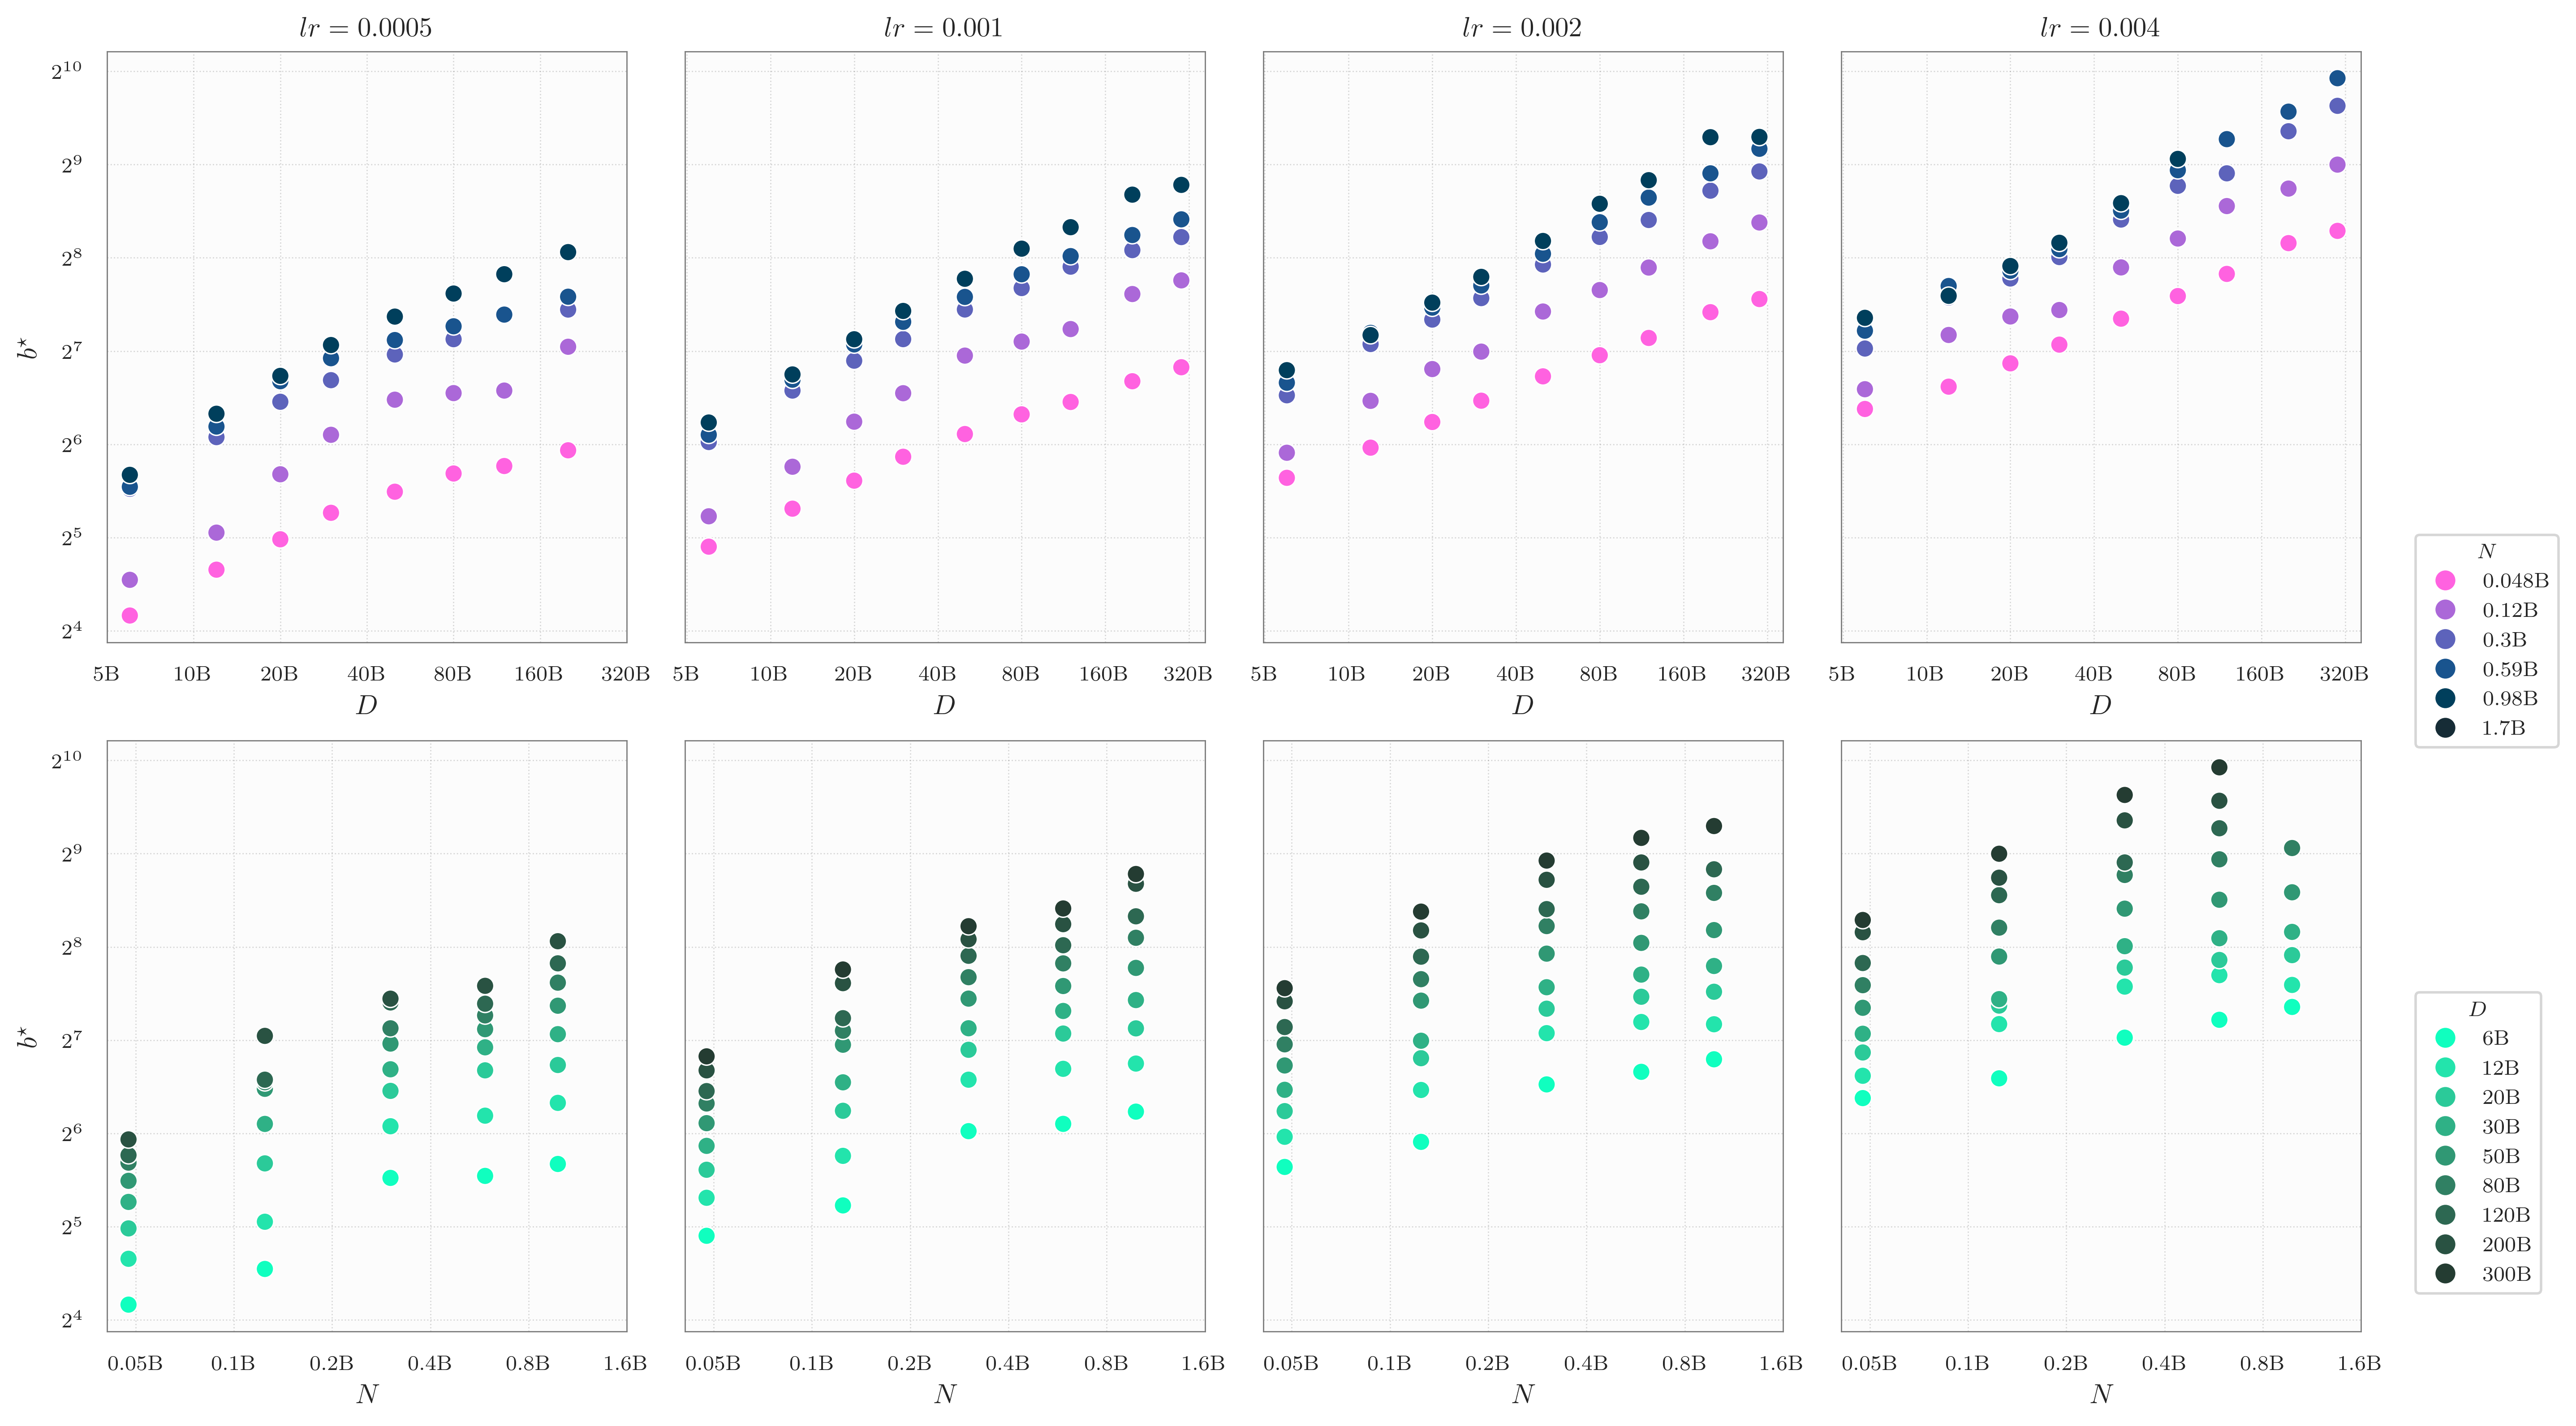

In [7]:
## Data Visualization
plot_hp_vs_ND_fix_other(
    df,
    y='gbsz',
    other_fixed='lr',
)

                            OLS Regression Results                            
Dep. Variable:                      b   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     1206.
Date:                Fri, 28 Aug 2026   Prob (F-statistic):          1.68e-137
Time:                        10:37:56   Log-Likelihood:                 140.90
No. Observations:                 172   AIC:                            -265.8
Df Residuals:                     164   BIC:                            -240.6
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.0467      0.008    604.712      0.0

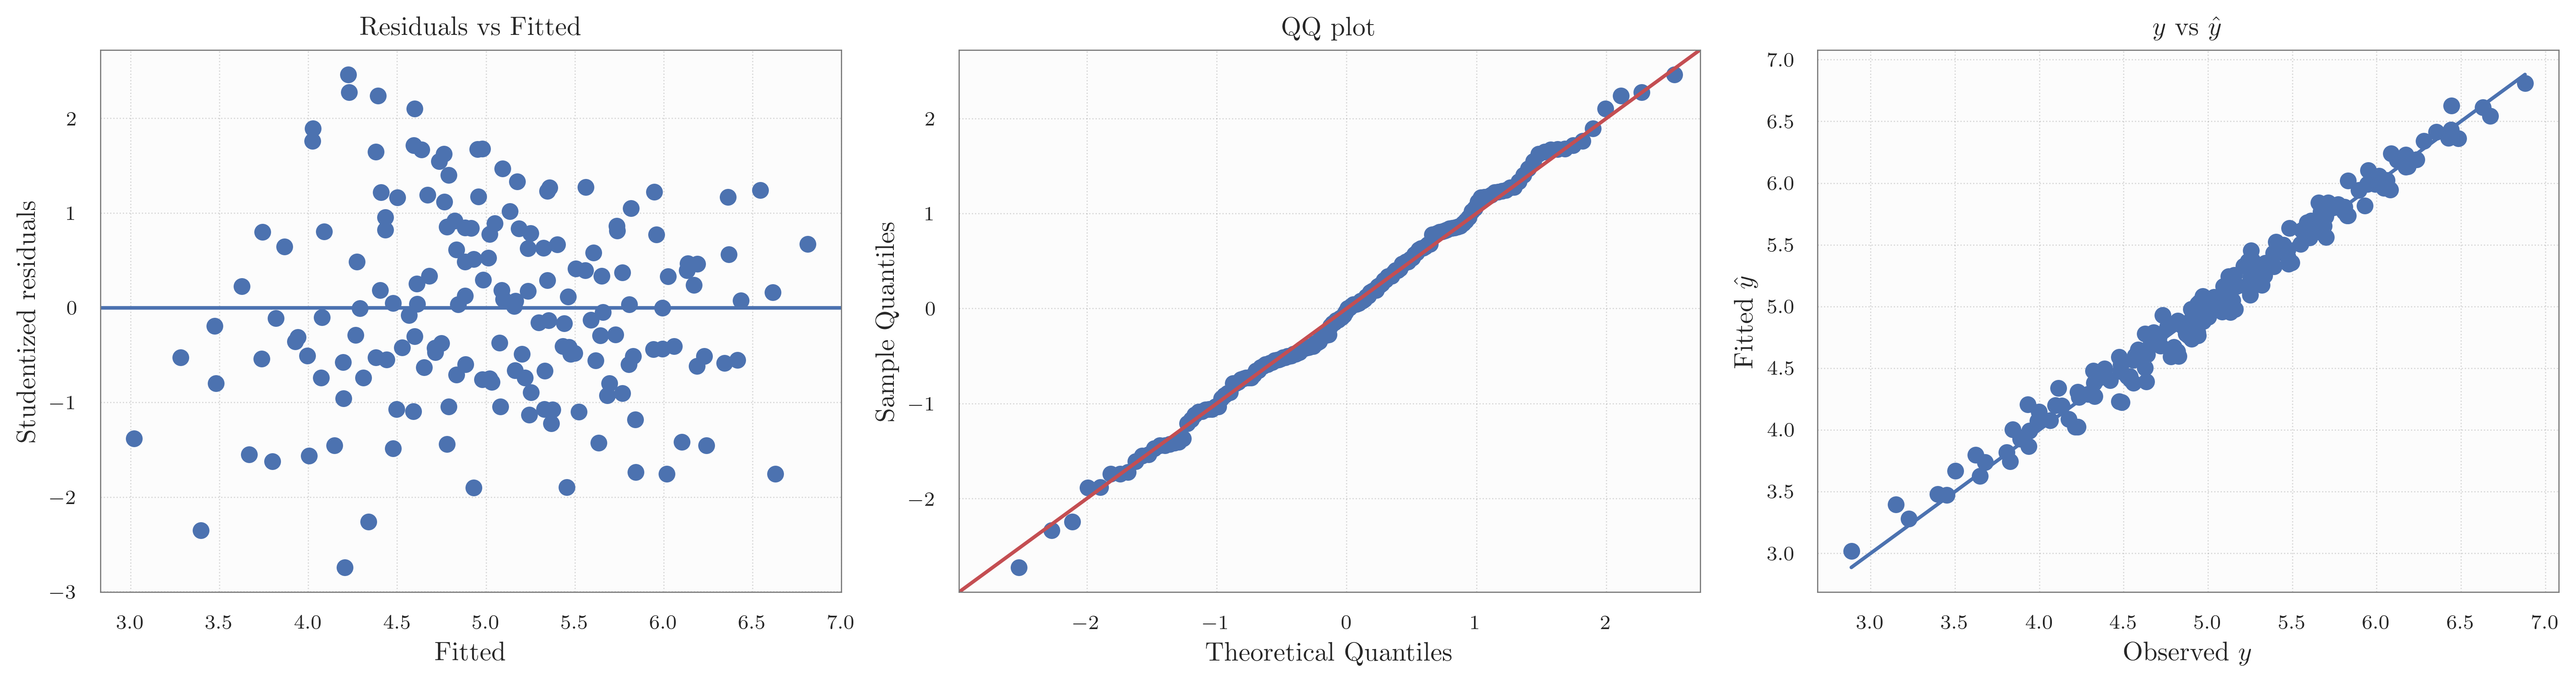

In [8]:
# --- Fit full model ---

df['b'] = np.log(df['gbsz'])
df['d'] = np.log(df['D'])
df['n'] = np.log(df['N'])
df['l'] = np.log(df['lr'])

# center
for v in ['d','n','l']:
    df[v] -= df[v].mean()

# interactions
df['dn']  = df['d'] * df['n']
df['dl']  = df['d'] * df['l']
df['nl']  = df['n'] * df['l']
df['dnl'] = df['d'] * df['n'] * df['l']

m_full = fit(df, y='b', x=['d','n','l','dn','dl','nl','dnl'])
print(m_full.summary())
plot_diagnostic(m_full)


In [9]:
# --- Build latex table from fit ---

rows = []

for name in m_full.params.index:

    coef = m_full.params[name]
    pval = m_full.pvalues[name]

    rows.append({
        "term": name,
        "coef": coef,
        "pvalue": pval,
    })

df_latex = pd.DataFrame(rows)

term_map = {
    "const": r"$\mathrm{const}$",
    "d": r"$\log D$",
    "n": r"$\log N$",
    "l": r"$\log \eta$",
    "dn": r"$\log D \log N$",
    "dl": r"$\log D \log \eta$",
    "nl": r"$\log N \log \eta$",
    "dnl": r"$\log D \log N \log \eta$",
}

df_latex["term"] = df_latex["term"].map(term_map)

def latex_fmt(x):
    if abs(x) < 1e-5:
        return r"$\approx 0$"
    return rf"${x:.5f}$"

latex_table = df_latex.to_latex(
    index=False,
    escape=False,
    column_format="lcc",
    caption=rf"Fitted coefficients and p-values for \autoref{{eq:b_vs_lrND_full_model}} (n={int(m_full.nobs)}, dof={int(m_full.df_resid)}, $R^2={m_full.rsquared.item():.3f}$).",
    label="tab:b_vs_lrND_full_model",
    formatters={"coef": latex_fmt, "pvalue": latex_fmt},
)

print(latex_table)

\begin{table}
\caption{Fitted coefficients and p-values for \autoref{eq:b_vs_lrND_full_model} (n=172, dof=164, $R^2=0.981$).}
\label{tab:b_vs_lrND_full_model}
\begin{tabular}{lcc}
\toprule
term & coef & pvalue \\
\midrule
$\mathrm{const}$ & $5.04673$ & $\approx 0$ \\
$\log D$ & $0.42089$ & $\approx 0$ \\
$\log N$ & $0.36163$ & $\approx 0$ \\
$\log \eta$ & $0.55507$ & $\approx 0$ \\
$\log D \log N$ & $0.03264$ & $\approx 0$ \\
$\log D \log \eta$ & $0.01929$ & $0.04132$ \\
$\log N \log \eta$ & $-0.05628$ & $\approx 0$ \\
$\log D \log N \log \eta$ & $0.01705$ & $0.05436$ \\
\bottomrule
\end{tabular}
\end{table}



In [10]:
## Can we drop triple interaction?

print(bootstrap_test_null(df, # H0: reduced model is true
    'b',
    ['d','n','l','dn','dl','nl','dnl'],
    ['d','n','l','dn','dl','nl'])[1].item())

## Yes, at ~5% significance level

0.0485


In [11]:
## Can we drop two interaction?

print(bootstrap_test_null(df, # H0: reduced model is true
    'b',
    ['d','n','l','dn','dl','nl','dnl'],
    ['d','n','l','dn','nl'])[1].item())

## Yes, at ~2% significance level

0.0195


In [12]:
## Can we adopt a very simple model?

print(bootstrap_test_null(df, # H0: reduced model is true
    'b',
    ['d','n','l','dn','dl','nl','dnl'],
    ['d','n','l'])[1])

## No

0.0


                            OLS Regression Results                            
Dep. Variable:                      b   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     1632.
Date:                Fri, 28 Aug 2026   Prob (F-statistic):          4.24e-139
Time:                        10:38:05   Log-Likelihood:                 136.99
No. Observations:                 172   AIC:                            -262.0
Df Residuals:                     166   BIC:                            -243.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.0467      0.008    595.464      0.0

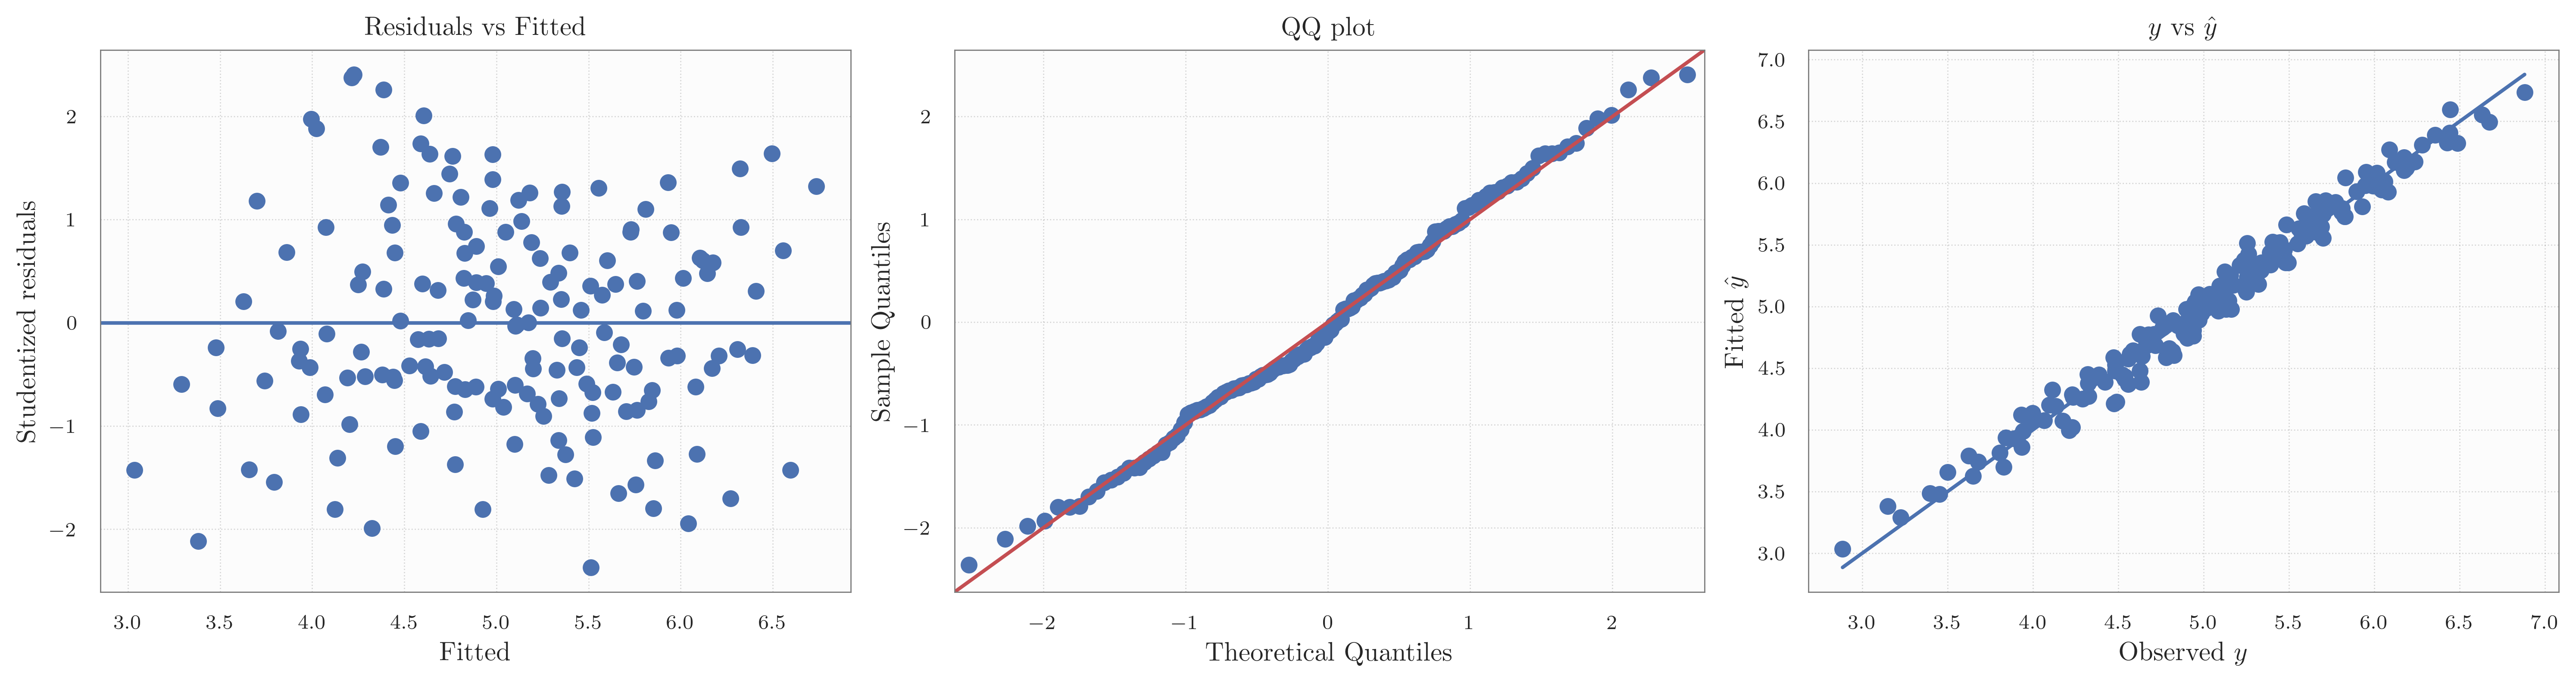

In [13]:
# --- Fit reduced model ---

df['b'] = np.log(df['gbsz'])
df['d'] = np.log(df['D'])
df['n'] = np.log(df['N'])
df['l'] = np.log(df['lr'])

# center
for v in ['d','n','l']:
    df[v] -= df[v].mean()

# interactions
df['dn']  = df['d'] * df['n']
df['nl']  = df['n'] * df['l']

m_reduced = fit(df, y='b', x=['d','n','l','dn','nl'])
print(m_reduced.summary())
plot_diagnostic(m_reduced)


In [14]:
p = m_reduced.params

print(rf"""
\begin{{equation}}
\log b^\star = 
{p['const']:+.2f}
{p['l']    :+.2f} \log \eta
{p['n']    :+.2f} \log N
{p['d']    :+.2f} \log D
{p['dn']   :+.2f} \log N) \log D
{p['nl']   :+.2f} \log N \log \eta.
\label{{eq:scaling_bsz_arbitrary_lr_fit_reduced}}
\end{{equation}}
""")


\begin{equation}
\log b^\star = 
+5.05
+0.55 \log \eta
+0.36 \log N
+0.42 \log D
+0.03 \log N) \log D
-0.06 \log N \log \eta.
\label{eq:scaling_bsz_arbitrary_lr_fit_reduced}
\end{equation}



### Plot fitted lines

In [15]:
# --- General settings ---

# df is the train set
df_plot = df.copy()

# Means used for centering
d0 = np.log(df['D']).mean()
n0 = np.log(df['N']).mean()
l0 = np.log(df['lr']).mean()

# Column values
lrs = [5e-4, 1e-3, 2e-3, 4e-3]
n_lrs = len(lrs)

# Axes grid
D_grid = np.geomspace(df['D'].min(), df['D'].max(), 200)
N_grid = np.geomspace(df['N'].min(), df['N'].max(), 200)

# Confidence intervals setting
CONF_LEVEL = 0.95
CONF_LABEL = f"{100*CONF_LEVEL:.0f}\\% CI"

# Plotting setting
fit_line_kwargs = {
    "linewidth": 1,
    "alpha": 0.9,
}
ci_kwargs = {
    "alpha": 0.1,
    "linewidth": 0.25,
}

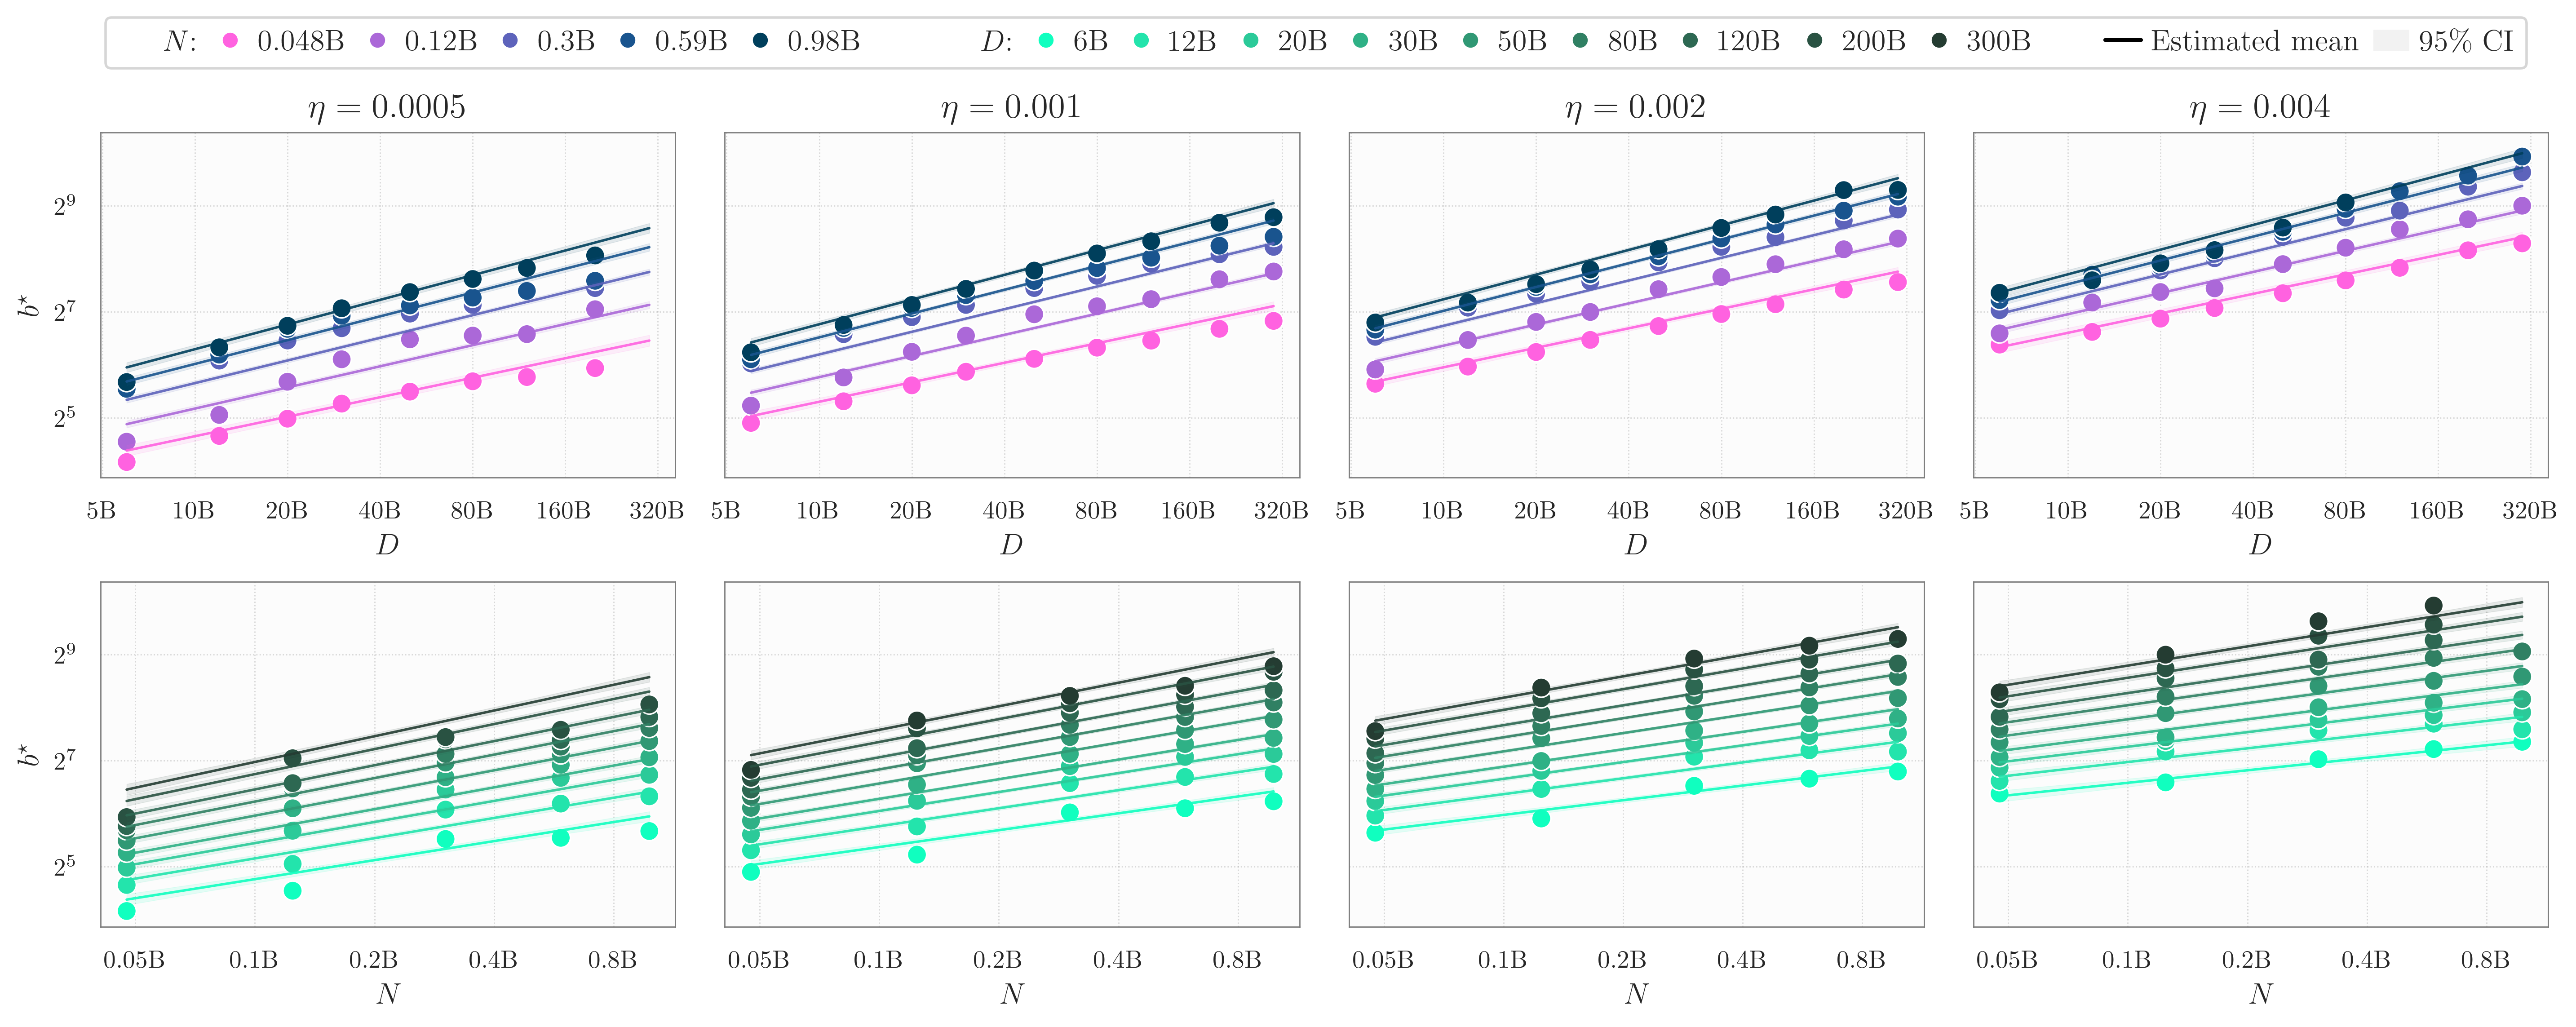

In [16]:
# -------------------------------------------------
# PLOT REDUCED MODEL FITS
# -------------------------------------------------

model = m_reduced

fig, axes = plt.subplots(
    2,
    n_lrs,
    figsize=(3.6 * n_lrs, 5.5),
    squeeze=False,
    sharey="all",
)

for c, lr in enumerate(lrs):

    df_b = df_plot[df_plot['lr'] == lr]

    # =================================================
    # ROW 0: b vs D
    # =================================================

    sns.scatterplot(
        data=df_b,
        x="D",
        y="gbsz",
        hue="N",
        palette=N_color_map,
        s=60,
        ax=axes[0, c]
    )

    for N, color in list(N_color_map.items())[:-1]:
        assert N <= 1e9, "1.7B should be reserved for validation!"

        X = pd.DataFrame({
            "d": np.log(D_grid) - d0,
            "n": np.log(N) - n0,
            "l": np.log(lr) - l0,
        })
        X['dn'] = X['d'] * X['n']
        X['nl'] = X['n'] * X['l']
        X = sm.add_constant(X, has_constant="add")
        sf = model.get_prediction(X).summary_frame(alpha=1-CONF_LEVEL)

        mean = np.exp(sf["mean"])
        lo   = np.exp(sf["mean_ci_lower"])
        hi   = np.exp(sf["mean_ci_upper"])

        axes[0, c].plot(D_grid, mean, color=color, **fit_line_kwargs)
        axes[0, c].fill_between(D_grid, lo, hi, color=color, **ci_kwargs)

    axes[0, c].set_xscale("log")
    axes[0, c].set_yscale("log", base=2)
    axes[0, c].set_title(rf"$\eta={lr}$", fontsize=14)
    axes[0, c].set_xlabel(r"$D$", fontsize=12)
    axes[0, c].set_ylabel(r"$b^\star$", fontsize=12)
    axes[0, c].set_xticks(D_ticks)
    axes[0, c].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: FORMAT_D(x)))
    axes[0, c].tick_params(axis="both", labelsize=10)
    axes[0, c].legend_.remove()

    # =================================================
    # ROW 1: b vs N
    # =================================================

    sns.scatterplot(
        data=df_b,
        x="N",
        y="gbsz",
        hue="D",
        palette=D_color_map,
        s=60,
        ax=axes[1, c]
    )

    for D, color in D_color_map.items():

        X = pd.DataFrame({
            "d": np.log(D) - d0,
            "n": np.log(N_grid) - n0,
            "l": np.log(lr) - l0,
        })
        X['dn'] = X['d'] * X['n']
        X['nl'] = X['n'] * X['l']
        X = sm.add_constant(X, has_constant="add")
        sf = model.get_prediction(X).summary_frame(alpha=1-CONF_LEVEL)

        mean = np.exp(sf["mean"])
        lo   = np.exp(sf["mean_ci_lower"])
        hi   = np.exp(sf["mean_ci_upper"])

        axes[1, c].plot(N_grid, mean, color=color, **fit_line_kwargs)
        axes[1, c].fill_between(N_grid, lo, hi, color=color, **ci_kwargs)

    axes[1, c].set_xscale("log")
    axes[1, c].set_yscale("log", base=2)
    axes[1, c].set_xlabel(r"$N$", fontsize=12)
    axes[1, c].set_ylabel(r"$b^\star$", fontsize=12)
    axes[1, c].set_xticks(N_ticks[:-1])
    axes[1, c].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: FORMAT_N(x)))
    axes[1, c].tick_params(axis="both", labelsize=10)
    axes[1, c].legend_.remove()

# =================================================
# Legend
# =================================================
    
handles = []

# N header
handles.append(Line2D([], [], linestyle="None", label=r"$N$:"))
handles += [
    Line2D([], [], marker="o", linestyle="None", markerfacecolor=c, markeredgecolor="none", markersize=6, label=FORMAT_N(N))
    for N, c in list(N_color_map.items())[:-1]
    
]
# spacer
handles.append(Line2D([], [], linestyle="None", label="   ")) 

# D header
handles.append(Line2D([], [], linestyle="None", label=r"$D$:"))
handles += [
    Line2D([], [], marker="o", linestyle="None", markerfacecolor=c, markeredgecolor="none", markersize=6, label=FORMAT_D(D))
    for D, c in D_color_map.items()
]
# spacer
handles.append(Line2D([], [], linestyle="None", label="   "))

# style entries
handles += [
    Line2D([0], [0], color="black", lw=1.5, label="Estimated mean"),
    Patch(facecolor="gray", alpha=ci_kwargs["alpha"], edgecolor="none", label=CONF_LABEL),
]

fig.legend(
    handles=handles,
    ncol=len(handles),
    loc="upper center",
    bbox_to_anchor=(0.51, 1.04),
    fontsize=12,
    frameon=True,
    handlelength=1.2,
    handletextpad=0.35,
    columnspacing=0.45,
)

# =================================================
# Show + save
# =================================================

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig("../fig/bsz_scaling/bsz_vs_ND_fit_reduced_model.pdf", dpi=400, bbox_inches='tight', pad_inches=0.02)
plt.show()

### Test predictions [reduced model]
We can use some 1.7B runs to asses goddness of these predictions.

In [17]:
# --- Predict with reduced model ---

# means used for centering
d_mean = np.log(df['D']).mean()
n_mean = np.log(df['N']).mean()
l_mean = np.log(df['lr']).mean()

# --------------------------------------------
# new prediction points
# --------------------------------------------

N_new = 1_713_504_256
D_new = [30e9, 50e9, 80e9]
lr_new = [2.5e-4, 5e-4, 1e-3, 2e-3]

df_pred = pd.DataFrame(list(itertools.product(D_new, lr_new)), columns=['D', 'lr'])
df_pred['N'] = N_new

# build covariates: center and take log, build interactions
df_pred['d'] = np.log(df_pred['D']) - d_mean
df_pred['n'] = np.log(df_pred['N']) - n_mean
df_pred['l'] = np.log(df_pred['lr']) - l_mean
df_pred['dn'] = df_pred['d'] * df_pred['n']
df_pred['nl'] = df_pred['n'] * df_pred['l']
        
# design matrix
X = df_pred[['d', 'n', 'l', 'dn', 'nl']]
X = sm.add_constant(X, has_constant='add')

# --------------------------------------------
# prediction on log(batch size)
# --------------------------------------------

pred = m_reduced.get_prediction(X).summary_frame(alpha=0.05)

df_pred['logb_pred'] = pred['mean']

# confidence interval
df_pred['logb_ci_lower'] = pred['mean_ci_lower']
df_pred['logb_ci_upper'] = pred['mean_ci_upper']

# prediction interval
df_pred['logb_pi_lo'] = pred['obs_ci_lower']
df_pred['logb_pi_hi'] = pred['obs_ci_upper']

# --------------------------------------------
# back to batch-size space
# --------------------------------------------

df_pred['b_pred'] = np.exp(df_pred['logb_pred'])

# CI
df_pred['b_ci_lower'] = np.exp(df_pred['logb_ci_lower'])
df_pred['b_ci_upper'] = np.exp(df_pred['logb_ci_upper'])

# PI
df_pred['b_pi_lo'] = np.exp(df_pred['logb_pi_lo'])
df_pred['b_pi_hi'] = np.exp(df_pred['logb_pi_hi'])

# display(df_pred)

table = df_pred.pivot_table(
    index='lr',
    columns='D',
    values=[
        'b_pred',
    ]
)
display(table)


b_pred                          
D       3.000000e+10 5.000000e+10 8.000000e+10
lr                                            
0.00025   121.157722   155.094513   194.657611
0.00050   164.131765   210.105766   263.701698
0.00100   222.348486   284.629237   357.235380
0.00200   301.214389   385.585814   483.944995

In [18]:
ANNOT_FONTSIZE = 12
TICK_FONTSIZE = 12
TITLE_FONTSIZE = 14
LABEL_FONTSIZE = 14
LEGEND_FONTSIZE = 12
CBAR_TITLE_FONTSIZE = 12

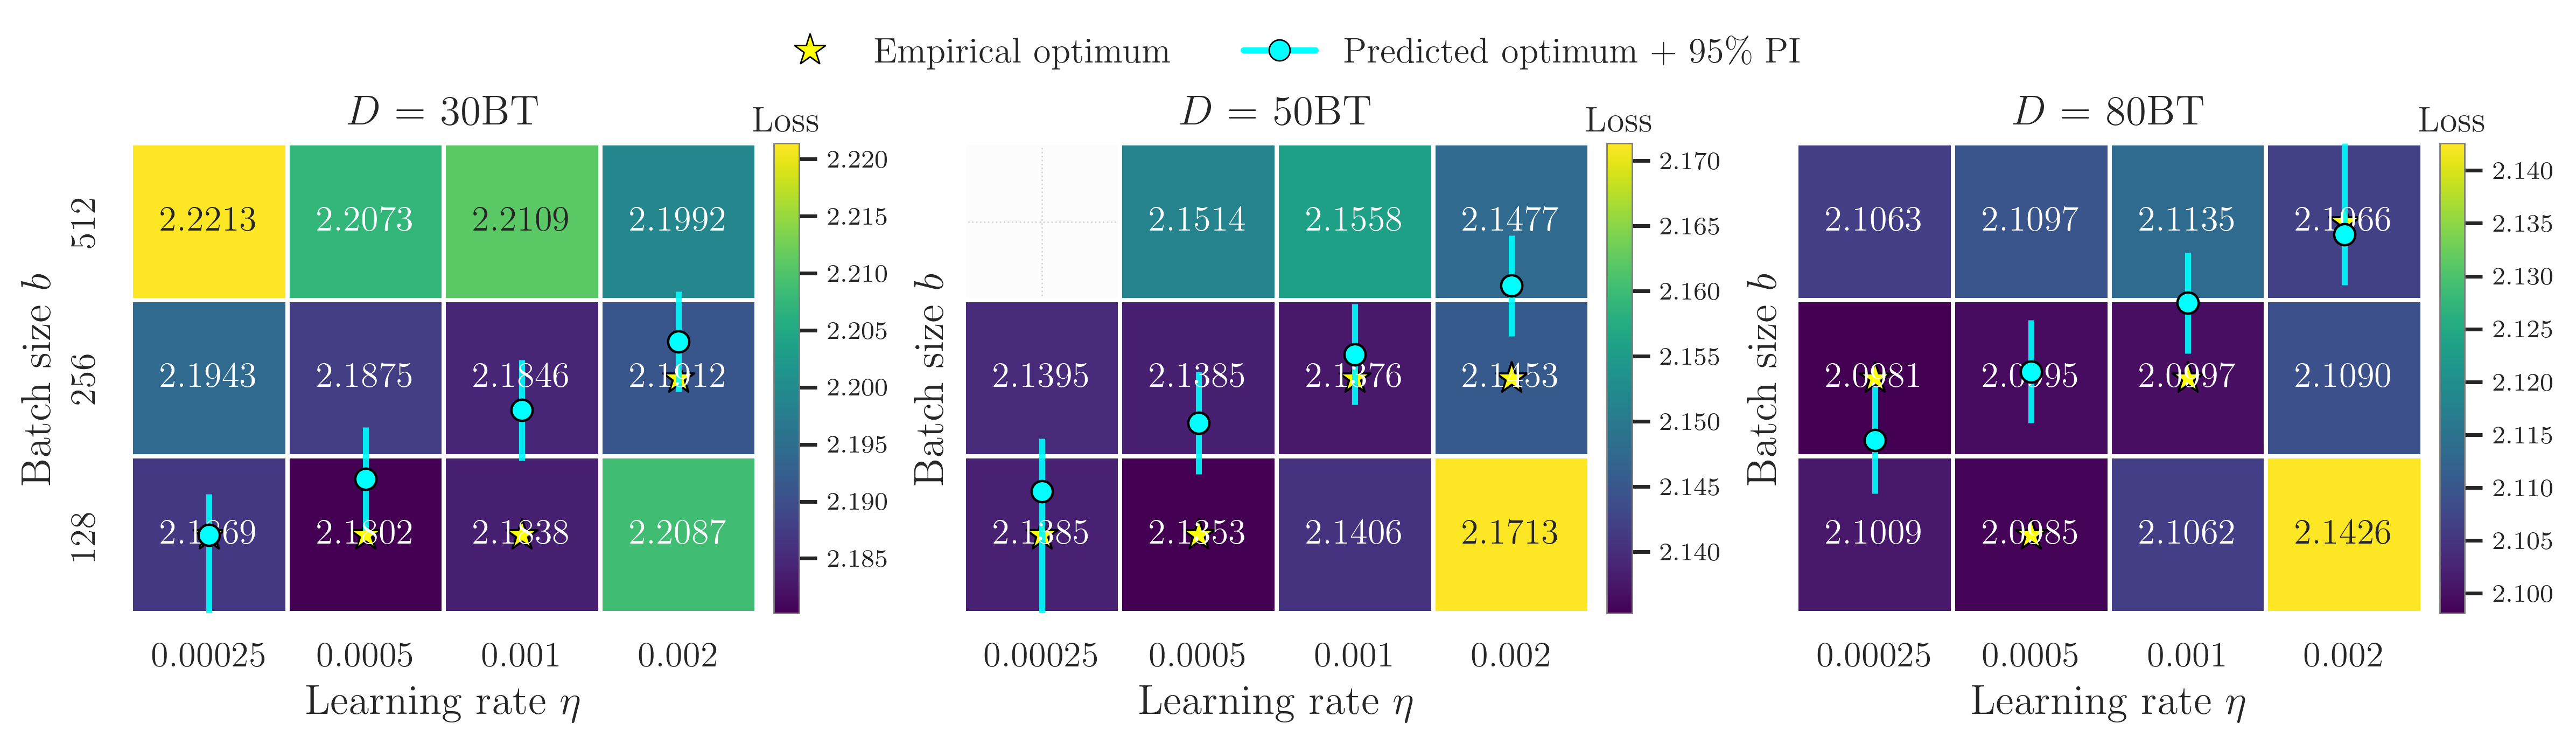

In [19]:
def heatmap_coord(value, values):
    """Map a value to heatmap cell-center coordinates."""
    return np.interp(np.log(value), np.log(values), np.arange(len(values))) + 0.5

def heatmap_boundary(value, values):
    """Map a value to heatmap coordinates, clipping to the heatmap boundaries."""
    if value <= values[0]:
        return 0.0
    if value >= values[-1]:
        return float(len(values))
    return np.interp(np.log(value), np.log(values), np.arange(len(values))) + 0.5

N = N_new
bszs = [128, 256, 512]
lr_new = [2.5e-4, 5e-4, 1e-3, 2e-3]

df_all = df_all[~(df_all.gbsz == 2048)]

fig, axes = plt.subplots(1, len(D_new), figsize=(4 * len(D_new), 4), sharey=True)

if len(D_new) == 1:
    axes = [axes]

for ax, D in zip(axes, D_new):

    gt = df_all[(df_all.N == N) & (df_all.D == D)]

    pivot = gt.pivot_table(index="gbsz", columns="lr", values="loss", aggfunc="min").reindex(index=bszs, columns=lr_new)

    hm = sns.heatmap(pivot, ax=ax, cmap="viridis", 
        annot_kws={"fontsize": ANNOT_FONTSIZE},
        annot=True, fmt=".4f", cbar=False, square=True, linewidths=1.1, linecolor="white")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.08)
    cbar = fig.colorbar(hm.collections[0], cax=cax)
    cbar.ax.set_title("Loss", pad=4, fontsize=CBAR_TITLE_FONTSIZE)
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))

    for txt in ax.texts:
        txt.set_zorder(20)

    ax.invert_yaxis()
    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)

    # ==========================================================
    # empirical optimum + predicted optimum + 95% PI
    # ==========================================================

    for x, lr in enumerate(lr_new):

        col = pivot[lr].values

        if np.all(np.isnan(col)):
            continue

        y_emp = np.nanargmin(col)

        ax.scatter(x + 0.5, y_emp + 0.5, marker="*", s=120, color="yellow", edgecolor="black", linewidth=0.7, zorder=10)

        pred = df_pred.query("D == @D and lr == @lr").iloc[0]

        # Point prediction
        y = heatmap_coord(pred["b_pred"], bszs)

        ax.scatter(x + 0.5, y, marker="o", s=50, facecolors="cyan", edgecolors="black", linewidth=0.8, zorder=21)

        # 95% PI — clipped to full heatmap boundaries
        y_lo = heatmap_boundary(pred["b_pi_lo"], bszs)
        y_hi = heatmap_boundary(pred["b_pi_hi"], bszs)

        ax.vlines(x + 0.5, y_lo, y_hi, color="cyan", linewidth=2, alpha=0.9, zorder=19)

    ax.set_title(f"$D$ = {FORMAT_D(D)}T", fontsize=TITLE_FONTSIZE)
    ax.set_xlabel(r"Learning rate $\eta$", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel(r"Batch size $b$", fontsize=LABEL_FONTSIZE)

# ==========================================================
# external legend
# ==========================================================

legend_handles = [
    Line2D([0], [0], marker="*", color="none", markerfacecolor="yellow", markeredgecolor="black", markersize=11, markeredgewidth=0.5, label="Empirical optimum"),
    Line2D([0], [0], marker="o", color="cyan", markerfacecolor="cyan", markeredgecolor="black", markersize=7, markeredgewidth=0.5, linewidth=2, label="Predicted optimum + 95\% PI"),
]

fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.91), ncol=2, frameon=False, fontsize=LEGEND_FONTSIZE)

plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig("../fig/bsz_scaling/predictions_1_7B_grid_reduced_model.pdf", dpi=400, bbox_inches="tight", pad_inches=0.02)

plt.show()

In [20]:
# Check D=30e9
print(df_pred[df_pred.D==30e9][['lr', 'b_pi_lo', 'b_pred', 'b_pi_hi']])

        lr     b_pi_lo      b_pred     b_pi_hi
0  0.00025   95.718542  121.157722  153.357890
1  0.00050  130.790084  164.131765  205.973077
2  0.00100  177.959133  222.348486  277.810126
3  0.00200  241.059455  301.214389  376.380624


### Predict quadratic fit minima
Now the same, but with contour lines of the estimated 2D quadratic.

In [21]:
# Loss observations across lr-bsz values for the 1.7B model
df_1_7B_all = df_all[((df_all.N == N_new) & (df_all.D.isin(D_new)))]
df_1_7B_all = df_1_7B_all.reset_index(drop=True)

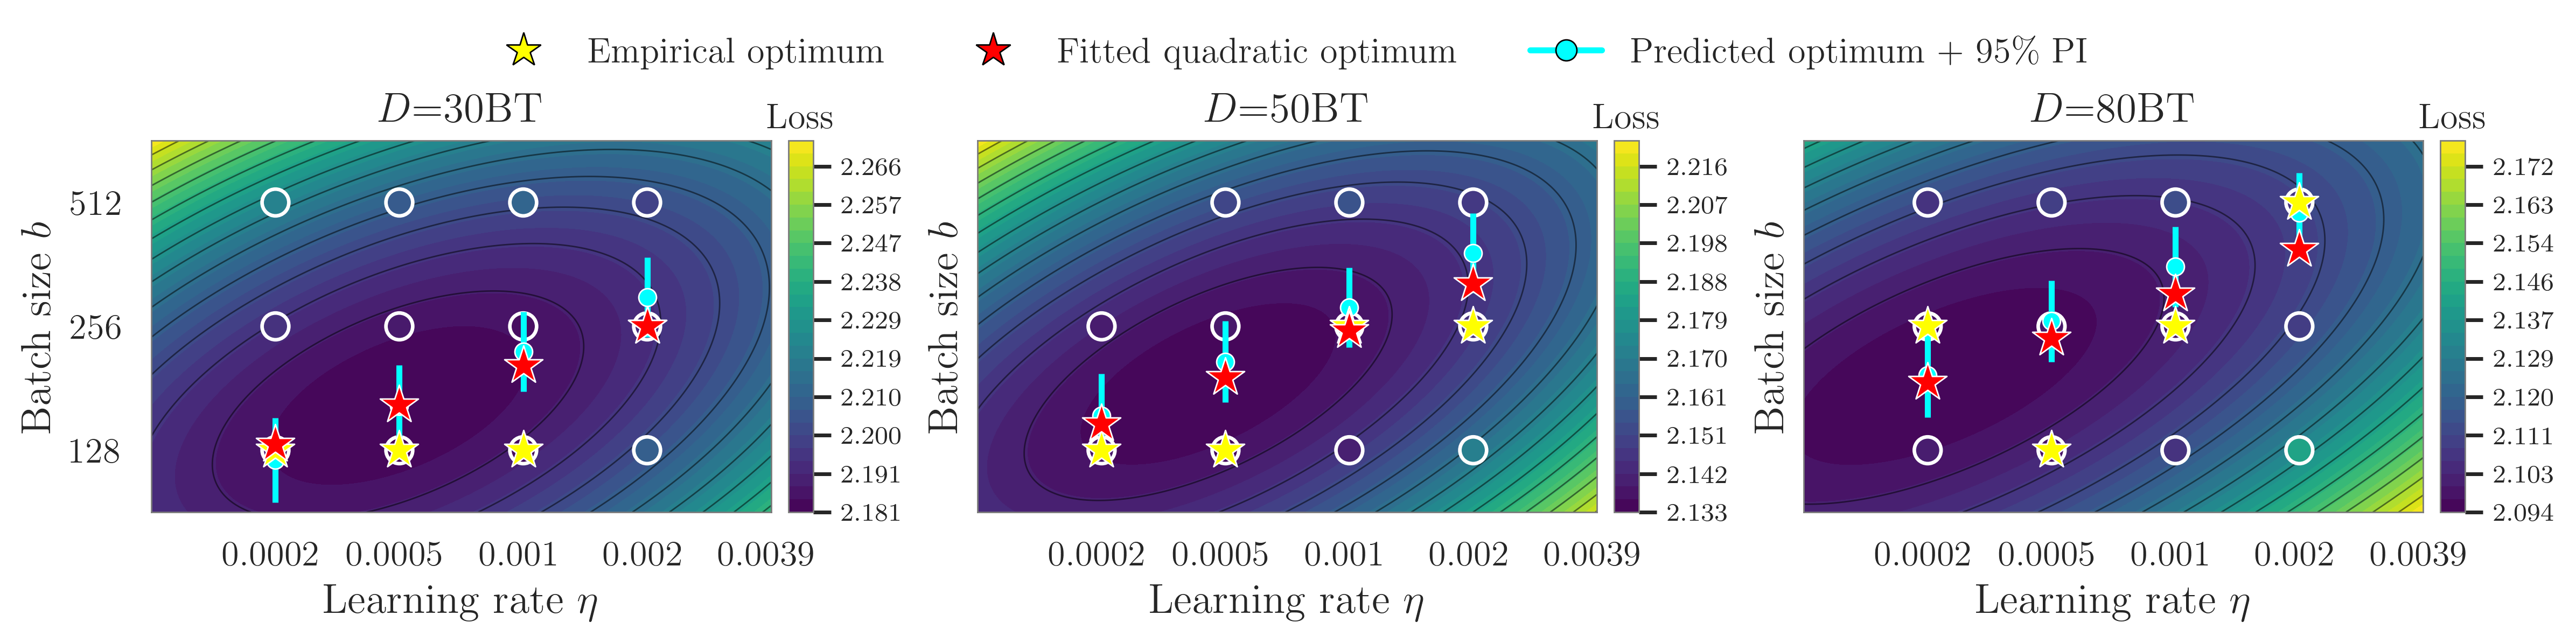

In [22]:
N = N_new

fig, axes = plt.subplots(1, len(D_new), figsize=(4 * len(D_new), 4), sharey=True)

lrs = np.sort(df_1_7B_all.lr.unique())
bszs = np.sort(df_1_7B_all.gbsz.unique())

if len(D_new) == 1:
    axes = [axes]

for ax, D in zip(axes, D_new):

    gt = df_1_7B_all[df_1_7B_all.D == D]

    fit_D = fit_2d_lr_gbsz[(fit_2d_lr_gbsz.N == N) & (fit_2d_lr_gbsz.D == D)].iloc[0]

    # ==========================================================
    # fitted quadratic surface
    # ==========================================================

    x_pad = 1.0
    y_pad = 0.5

    x_vals = np.linspace(np.log2(lrs.min()) - x_pad, np.log2(lrs.max()) + x_pad, 200)
    y_vals = np.linspace(np.log2(bszs.min()) - y_pad, np.log2(bszs.max()) + y_pad, 200)

    X, Y = np.meshgrid(x_vals, y_vals)

    a, b, c, d, e, f_coef = fit_D.coef

    Z = a + b * X + c * X**2 + d * Y + e * Y**2 + f_coef * X * Y

    vmin = Z.min()
    vmax = Z.max()

    cf = ax.contourf(X, Y, Z, levels=np.linspace(vmin, vmax, 30), cmap="viridis")

    ax.contour(X, Y, Z, levels=np.linspace(vmin, vmax, 15), colors="black", linewidths=0.5, alpha=0.5)

    # ==========================================================
    # measured grid
    # ==========================================================

    ax.scatter(np.log2(gt.lr), np.log2(gt.gbsz), c=gt.loss, cmap="viridis", vmin=vmin, vmax=vmax, s=80, edgecolors="white", linewidths=1.2, zorder=3)

    # ==========================================================
    # predicted optimum batch size for each observed learning rate
    # ==========================================================

    pred_D = df_pred[df_pred.D == D].sort_values("lr")

    for _, pred in pred_D.iterrows():

        lr = pred.lr

        x = np.log2(lr)
        y = np.log2(pred.b_pred)

        # PI clipped only to plotted contour boundaries
        y_lo = max(np.log2(pred.b_pi_lo), y_vals.min())
        y_hi = min(np.log2(pred.b_pi_hi), y_vals.max())

        # prediction interval
        ax.vlines(x, y_lo, y_hi, color="cyan", linewidth=2, zorder=20)

        # point prediction
        ax.scatter(x, y, s=35, color="cyan", edgecolors="white", linewidths=0.5, zorder=21)

        # empirical optimum for this learning rate
        row = gt[gt.lr == lr]

        if len(row):
            emp = row.loc[row.loss.idxmin()]

            ax.scatter(np.log2(emp.lr), np.log2(emp.gbsz), marker="*", s=180, c="yellow", edgecolors="white", linewidths=0.5, zorder=30)

        # fitted optimum for this learning rate (sliced)
        best = df_best_gbsz_sliced[(df_best_gbsz_sliced.N == N) & (df_best_gbsz_sliced.D == D) & (df_best_gbsz_sliced.lr == lr)]

        if not best.empty:

            b_star = best["gbsz"].iloc[0]

            ax.scatter(np.log2(lr), np.log2(b_star), marker="*", s=180, c="red", edgecolors="white", linewidths=0.5, zorder=30)

    # ==========================================================
    # axes
    # ==========================================================

    xticks = np.arange(np.floor(x_vals.min()), np.ceil(x_vals.max()))
    yticks = np.arange(np.floor(y_vals.min()), np.ceil(y_vals.max()))

    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_xticklabels([f"{2**x:.4f}".rstrip("0").rstrip(".") for x in xticks])
    ax.set_yticklabels([f"{2**y:.0f}" for y in yticks])
    ax.set_xlim(x_vals.min(), x_vals.max())
    ax.set_ylim(y_vals.min(), y_vals.max())
    ax.set_aspect("equal")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.08)
    cbar = fig.colorbar(cf, cax=cax)
    cbar.ax.set_title("Loss", pad=4, fontsize=CBAR_TITLE_FONTSIZE)
    ax.set_xticklabels([f"{2**x:.4f}".rstrip("0").rstrip(".") for x in xticks])

    ax.set_title(f"$D$={FORMAT_D(D)}T", fontsize=TITLE_FONTSIZE)
    ax.set_xlabel(r"Learning rate $\eta$", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel(r"Batch size $b$", fontsize=LABEL_FONTSIZE)
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))

# ==========================================================
# external legend
# ==========================================================

legend_handles = [
    Line2D([0], [0], marker="*", color="none", markerfacecolor="yellow", markeredgecolor="black", markersize=12, markeredgewidth=0.5, label="Empirical optimum"),
    Line2D([0], [0], marker="*", color="none", markerfacecolor="red", markeredgecolor="black", markersize=12, markeredgewidth=0.5, label="Fitted quadratic optimum"),
    Line2D([0], [0], marker="o", color="cyan", markerfacecolor="cyan", markeredgecolor="black", markersize=7, markeredgewidth=0.5, linewidth=2, label="Predicted optimum + 95\% PI"),
]

fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.85), ncol=3, frameon=False, fontsize=LEGEND_FONTSIZE)

plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig("../fig/bsz_scaling/predictions_1_7B_contour_reduced_model.pdf", dpi=400, bbox_inches="tight", pad_inches=0.02)


plt.show()